In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fast_borf.weighted.borf_multi import BorfPipelineBuilder as BorfBuilder
from fast_borf.pipeline.zero_columns_remover import ZeroColumnsRemover
from fast_borf.pipeline.reshaper import ReshapeTo2D
from fast_borf.pipeline.to_scipy import ToScipySparse
from fast_borf.xai.mapping import BagOfReceptiveFields
from aeon.datasets import load_classification
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from shap import LinearExplainer
from matplotlib.colors import CenteredNorm
from scipy.spatial.distance import cdist
from matplotlib.collections import LineCollection
import matplotlib.ticker as ticker
import matplotlib

In [83]:
# X_train, y_train = load_classification("CBF", split="train")
# X_test, y_test = load_classification("CBF", split="test")
# X_train.shape, y_train.shape, X_test.shape, y_test.shape
# enc = LabelEncoder()
# y_train = enc.fit_transform(y_train)
# y_test = enc.transform(y_test)

In [84]:
# # inject NaNs
# X_train[:, :, 10:40] = np.nan

In [85]:
from irregular_ts.data_utils import data_new_folder
import xarray as xr
df = xr.open_dataset(data_new_folder() / "Abf.h5", engine="my_engine")["data"]
y, split = df.irr.get_task_target_and_split()
X, _ = df.irr.to_dense(
    concatenate_time=True,
    normalize_time=True,
)
train_idxs, test_idxs = split == "train", split == "test"
X_train, y_train = X[train_idxs], y[train_idxs]
X_test, y_test = X[test_idxs], y[test_idxs]
X_train.shape

(30, 2, 128)

In [86]:
pipe = make_pipeline(BorfBuilder(
    min_window_to_signal_std_ratio=0.15,
    contains_time_idx=True,
    pipeline_objects=[
        (ReshapeTo2D, dict(keep_unraveled_index=True)),
        (ZeroColumnsRemover, dict(axis=0)),
        (ToScipySparse, dict()),
        ],
).build(X_train), FunctionTransformer(np.arcsinh),
                     RidgeClassifierCV())

In [87]:
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warning

0.9

In [88]:
borf = pipe[0]
mapper = BagOfReceptiveFields(borf)
print(len(mapper.mapping))

8780


In [89]:
mapper.configs

[{'alphabet_size': 3,
  'contains_time_idx': True,
  'dilation': 1,
  'min_window_to_signal_std_ratio': 0.15,
  'n_jobs': 1,
  'prefix': '',
  'stride': 1,
  'window_size': 4,
  'word_length': 2},
 {'alphabet_size': 3,
  'contains_time_idx': True,
  'dilation': 1,
  'min_window_to_signal_std_ratio': 0.15,
  'n_jobs': 1,
  'prefix': '',
  'stride': 1,
  'window_size': 4,
  'word_length': 4},
 {'alphabet_size': 3,
  'contains_time_idx': True,
  'dilation': 2,
  'min_window_to_signal_std_ratio': 0.15,
  'n_jobs': 1,
  'prefix': '',
  'stride': 1,
  'window_size': 4,
  'word_length': 2},
 {'alphabet_size': 3,
  'contains_time_idx': True,
  'dilation': 2,
  'min_window_to_signal_std_ratio': 0.15,
  'n_jobs': 1,
  'prefix': '',
  'stride': 1,
  'window_size': 4,
  'word_length': 4},
 {'alphabet_size': 3,
  'contains_time_idx': True,
  'dilation': 4,
  'min_window_to_signal_std_ratio': 0.15,
  'n_jobs': 1,
  'prefix': '',
  'stride': 1,
  'window_size': 4,
  'word_length': 2},
 {'alphabet_siz

In [90]:
borf.transformer_list[0]

('0',
 Pipeline(steps=[('borfsaxsingletransformer',
                  BorfSaxSingleTransformer(min_window_to_signal_std_ratio=0.15)),
                 ('reshapeto2d', ReshapeTo2D(keep_unraveled_index=True)),
                 ('zerocolumnsremover', ZeroColumnsRemover()),
                 ('toscipysparse', ToScipySparse())]))

In [91]:
n = 30
mapper.build(np.array(X_train)[:n], y_train[:n], pipe.predict(X_train[:n]), task="classification")

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warning

In [92]:
mapper.timestamps_

array([[[0.        , 0.01602411, 0.02599416, ..., 0.7977246 ,
         0.81926882, 1.        ]],

       [[0.        , 0.03850222, 0.0864618 , ..., 0.88093078,
         0.89359074, 1.        ]],

       [[0.        , 0.02288947, 0.02673639, ..., 0.91501665,
         0.92307287, 1.        ]],

       ...,

       [[0.        , 0.00890393, 0.04054371, ..., 0.94196087,
         0.94563353, 1.        ]],

       [[0.        , 0.05388296, 0.12110479, ..., 0.99337333,
         0.99691188, 1.        ]],

       [[0.        , 0.11163622, 0.1510107 , ..., 0.98494404,
         0.99753767, 1.        ]]])

In [93]:
print(mapper.receptive_fields_[0])

[0 1] - (signal:0, window_size:4, word_length:2, dilation:1, stride:1)


In [94]:
mapper.receptive_fields_[1].alignments#, mapper.receptive_fields_[0].mappings

[array([[[0.29201486, 0.29238852],
         [0.29365709, 0.29436612]],
 
        [[0.30944648, 0.31197687],
         [0.314168  , 0.31911277]],
 
        [[0.31197687, 0.314168  ],
         [0.31911277, 0.32267811]],
 
        [[0.38354346, 0.38649868],
         [0.39069271, 0.39957535]],
 
        [[0.44651558, 0.45400243],
         [0.46800506, 0.47627934]],
 
        [[0.45400243, 0.46800506],
         [0.47627934, 0.47931307]],
 
        [[0.49318784, 0.50280642],
         [0.50777328, 0.51168674]],
 
        [[0.50280642, 0.50777328],
         [0.51168674, 0.51323139]],
 
        [[0.54794543, 0.55290633],
         [0.55389916, 0.55445963]],
 
        [[0.55290633, 0.55389916],
         [0.55445963, 0.55717903]],
 
        [[0.5829944 , 0.58737146],
         [0.58966487, 0.59284818]],
 
        [[0.58737146, 0.58966487],
         [0.59284818, 0.59709465]],
 
        [[0.61610043, 0.63678902],
         [0.64509016, 0.64782106]],
 
        [[0.68501204, 0.72462397],
         [0.7596

In [95]:
i = 0
x = X_train[i, 0].ravel()
timestamps = X_train[i, 1].ravel()

indices = np.arange(len(x))
nan_mask = np.isnan(x)

# Interpolated values at NaN positions
interpolated_values = np.interp(indices[nan_mask], indices[~nan_mask], x[~nan_mask])

# Full signal with NaNs replaced
x_filled = x.copy()
x_filled[nan_mask] = interpolated_values

# Signal with only interpolated values (NaN elsewhere)
x_interp_only = np.full_like(x, np.nan)
x_interp_only[nan_mask] = interpolated_values

In [96]:
x.shape

(128,)

In [97]:
mapper.timestamps_[i]

array([[0.        , 0.01602411, 0.02599416, 0.03188649, 0.06419948,
        0.09486326, 0.09657098, 0.11878754, 0.14739045, 0.15126502,
        0.15152849, 0.1710764 , 0.17606817, 0.19625952, 0.21389918,
        0.21935585, 0.22568352, 0.23115718, 0.23368726, 0.23482884,
        0.2351064 , 0.23628982, 0.23696957, 0.23805202, 0.2423643 ,
        0.24383504, 0.24449791, 0.25196498, 0.25545197, 0.26710397,
        0.27089864, 0.27106308, 0.27237465, 0.27301901, 0.27679955,
        0.283571  , 0.28455439, 0.29201486, 0.29238852, 0.29365709,
        0.29436612, 0.29946479, 0.30072852, 0.30772742, 0.30944648,
        0.31197687, 0.314168  , 0.31911277, 0.32267811, 0.33747795,
        0.3385629 , 0.34164211, 0.34204351, 0.342469  , 0.34605363,
        0.34780198, 0.34909132, 0.35282298, 0.35697001, 0.35784053,
        0.35849842, 0.36113163, 0.36144101, 0.36187627, 0.37519782,
        0.37943187, 0.38030022, 0.38125443, 0.38354346, 0.38649868,
        0.39069271, 0.39957535, 0.40911129, 0.41

In [98]:
mapper.receptive_fields_[k].alignments[i][j].ravel()

array([0.29201486, 0.29238852, 0.29365709, 0.29436612])

[0 2] - (signal:0, window_size:4, word_length:2, dilation:1, stride:1)


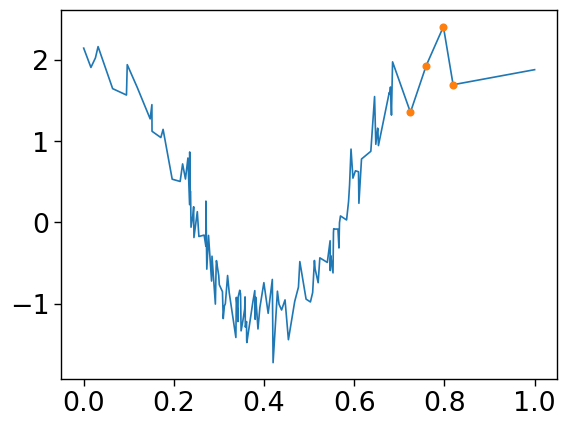

In [99]:
j = -1
k = 1
plt.plot(timestamps, x)
plt.plot(mapper.receptive_fields_[k].alignments[i][j].ravel(), mapper.receptive_fields_[k].mappings[i][j].ravel(), 'o')
# plt.plot(indices, x_interp_only, 'lightgray', label='Interpolated Signal', linestyle='dotted')
# plt.plot(mapper.receptive_fields_[k].alignments[i][j+4].ravel(), mapper.receptive_fields_[k].mappings[i][j+4].ravel(), 'o')
print(mapper.receptive_fields_[k])

In [100]:
X_tr_n = borf.transform(np.array(X_train)[:n])
exp = LinearExplainer(pipe[-1], X_tr_n)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warning

In [101]:
F = exp.shap_values(X_tr_n).swapaxes(1, 2).swapaxes(0, 1)  # (n_classes, n_samples, n_features)
F.shape

(3, 30, 8780)

In [102]:
mapper.add_feature_importance(F)
mapper.map_contained_feature_importance_to_saliency(count_overlapping=False)
mapper.map_notcontained_feature_importance()

/Users/francesco/github/borf/fast_borf/xai/mapping.py:217: SparseEfficiencyWarning: Comparing a sparse matrix with 0 using == is inefficient, try using != instead.
  F_single_norm = self.map_single_notcontained_feature_importance(i)


In [103]:
mapper.y_pred_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [104]:
mapper.F_.shape

(30, 8780)

In [105]:
mapper.S_[0]

array([[0.0025196 , 0.00384289, 0.00372382, 0.00302247, 0.0028569 ,
        0.00480591, 0.00517221, 0.00469147, 0.00473083, 0.00573391,
        0.00521004, 0.00594852, 0.00622227, 0.0067265 , 0.00402727,
        0.00588842, 0.0043855 , 0.00589518, 0.00328226, 0.00534274,
        0.00411702, 0.00687323, 0.00521058, 0.00634258, 0.0062826 ,
        0.00762364, 0.00731609, 0.00711916, 0.00794702, 0.00942625,
        0.00866654, 0.0094863 , 0.00796898, 0.01027152, 0.00980475,
        0.01077546, 0.01161432, 0.01362398, 0.01510749, 0.01418491,
        0.014576  , 0.01529293, 0.0165915 , 0.01615906, 0.01863941,
        0.01876648, 0.01874078, 0.02141624, 0.01907078, 0.01997258,
        0.02028928, 0.02251025, 0.01907596, 0.02113125, 0.02003672,
        0.02420909, 0.02022903, 0.02123159, 0.02181484, 0.02554103,
        0.02286457, 0.02126192, 0.02107263, 0.02365436, 0.02184045,
        0.01957909, 0.02008644, 0.02353607, 0.0227377 , 0.02074935,
        0.02172819, 0.02358507, 0.01985242, 0.01

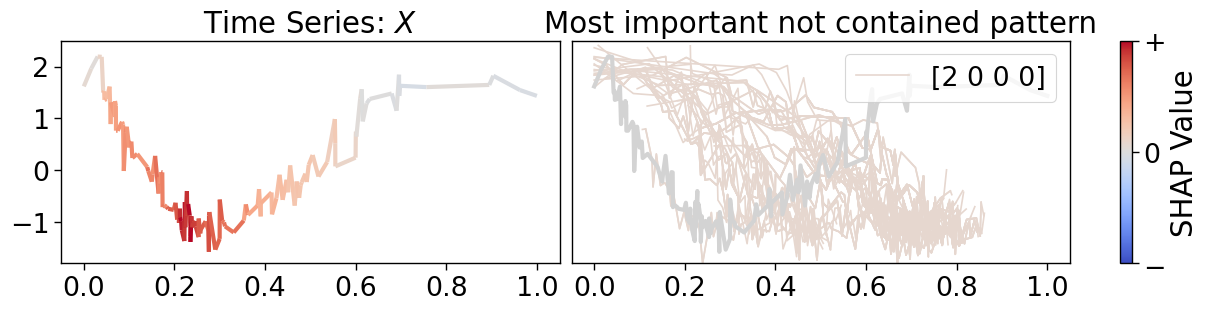

In [114]:
i = 12

sns.set_context("paper", font_scale=2.2)

y_true = mapper.y_true_[i]
y_pred = mapper.y_pred_[i]
x_tr = mapper.X_transformed_[i].toarray()
f_norm = mapper.F_norm_[i]
signal_idxs = mapper.mapping[:, 1]
zero_indices = np.argwhere(x_tr == 0)[:, 1]
num_signals = np.max(signal_idxs) + 1
sorted_indices_by_signal = []

for signal in range(num_signals):
    signal_indices = zero_indices[signal_idxs[zero_indices] == signal]
    
    if len(signal_indices) > 0:
        filtered_importance = f_norm[signal_indices]
        abs_importance = np.abs(filtered_importance)
        sorted_indices = np.argsort(-abs_importance)
        sorted_original_indices = signal_indices[sorted_indices]
        sorted_indices_by_signal.append(sorted_original_indices)
    
    else:
        sorted_indices_by_signal.append(np.array([]))

all_values = np.concatenate([mapper.S_[i].ravel(), f_norm[~np.isnan(f_norm)]])

cmap = plt.get_cmap('coolwarm')
norm = CenteredNorm()
norm(all_values)
fig, axs = plt.subplots(len(mapper.X_[0]), 2, figsize=(12, num_signals*3), width_ratios=[1, 1], sharey=True, sharex=False, squeeze=False, layout="constrained")

for j in range(len(mapper.X_[0])):
    x = mapper.X_[i, j]
    timestamps = mapper.timestamps_[i, j]
    s = mapper.S_[i, j]
    y_true = mapper.y_true_[i]
    y_pred = mapper.y_pred_[i]
    x_tr = mapper.X_transformed_[i].toarray()
    line_colors = cmap(norm(s.ravel()))
    points = np.array([timestamps, (x-np.nanmean(x))/np.nanstd(x)]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm, lw=3)
    lc.set_array(s)
    axs[j, 0].add_collection(lc)
    axs[j, 0].autoscale()
    axs[j, 0].grid(False)
    axs[j, 0].tick_params(axis='both', which='both', bottom=True, top=False, left=True, right=False)
    axs[j, 0].yaxis.set_major_locator(ticker.MultipleLocator(1))
    axs[j, 0].set_title(r"Time Series: $X$")
    
    rfield = mapper.receptive_fields_[sorted_indices_by_signal[j][0]]
    rfields = np.vstack(rfield.mappings)
    rfields = rfields.reshape(rfields.shape[0], -1)
    rfields_idxs = np.vstack(rfield.alignments)
    rfields_idxs = rfields_idxs.reshape(rfields.shape[0], -1)
    rfields_idx = rfield.plot_idx
    rfields_mean = rfields.mean(axis=1)
    rfields_std = rfields.std(axis=1)
    avg_starting_idx = np.floor(np.median(np.vstack(rfield.alignments_indices)[:, 0, 0])).astype(int)
    min_idx = np.min(np.vstack(rfield.alignments_indices))
    max_idx = np.max(np.vstack(rfield.alignments_indices))
    rfields_norm = (rfields - rfields_mean[:, np.newaxis]) / (rfields_std[:, np.newaxis] + 1e-6) * ((x-x.mean())/x.std())[avg_starting_idx + rfields_idx].std() + ((x-x.mean())/x.std())[avg_starting_idx + rfields_idx].mean()
    rfields_norm = rfields
    rfield_importance = rfield.feature_importance_norm[i]
    rfield_centroid = rfields_norm.mean(axis=0)
    rfield_qt5 = np.median(rfields_norm, axis=0)
    rfield_qt25 = np.percentile(rfields_norm, 25, axis=0)
    rfield_qt75 = np.percentile(rfields_norm, 75, axis=0)
    
    distances = cdist(rfields_norm, rfields_norm, metric='euclidean')
    medoid_index = np.argmin(distances.sum(axis=0))
    rfield_medoid = rfields_norm[medoid_index]
    axs[j, 1].plot(rfields_idxs[0], rfields_norm[0], zorder=0, c=cmap(norm(rfield_importance)), label=f"{rfield.word_array}")
    axs[j, 1].plot(rfields_idxs.T, rfields_norm.T, zorder=0, c=cmap(norm(rfield_importance)))
    axs[j, 1].set_title(f"Most important not contained pattern")
    axs[j, 1].plot(timestamps, (x-x.mean())/x.std(), c='lightgray', lw=3)
    # axs[j, 1].plot(avg_starting_idx + rfields_idx, rfield_medoid, c=cmap(norm(rfield_importance)), lw=5, linestyle='-', alpha=1, label=f"{rfield.word_array}")
    axs[j, 1].grid(False)
    axs[j, 1].tick_params(axis='both', which='both', bottom=True, top=False, left=False, right=False)
    axs[j, 1].set_ylim(-1.8, 2.5)
    plt.legend()
   

sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axs)
cbar.set_ticks([norm.vmin, 0, norm.vmax])
cbar.set_ticklabels([r'$-$', '0', r'$+$'])
cbar.set_label("SHAP Value")
plt.show()

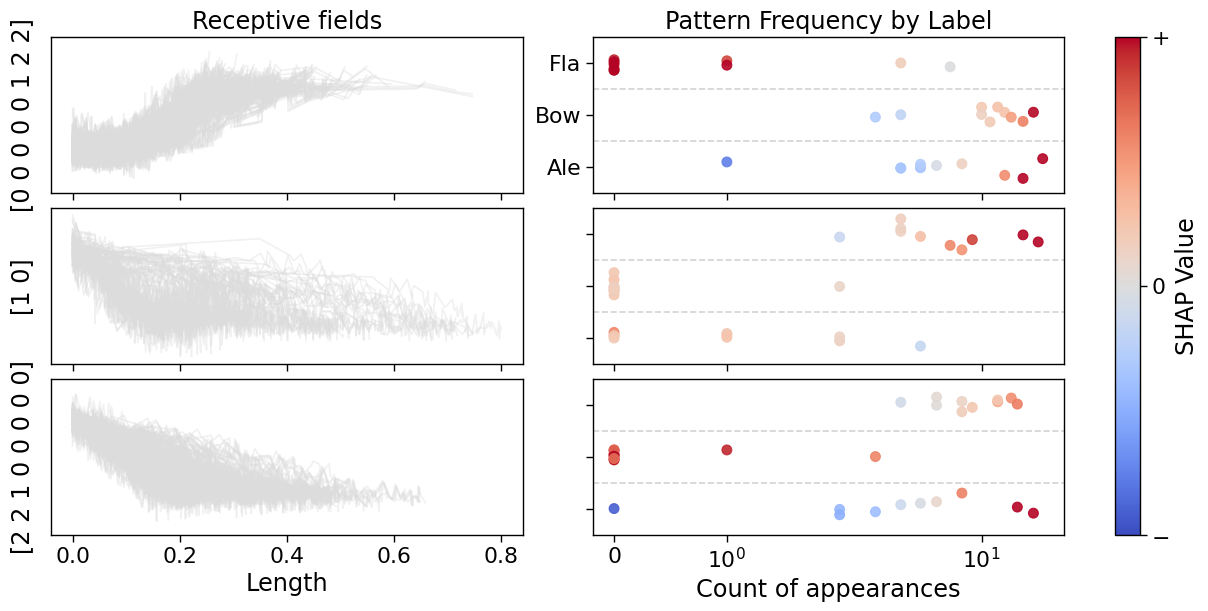

In [125]:
labels = ["Ale", "Bow", "Fla"]
def rand_jitter(arr, jitter_multiplier=0.05):
    stdev = jitter_multiplier * (max(arr) - min(arr))
    return arr + np.random.randn(len(arr)) * stdev

def jitter(x, y, ax=None, jitter_x=True, jitter_y=True, jitter_multiplier=0.05, **kwargs):
    if ax is None:
        ax = plt.gca()
    if jitter_x:
        x = rand_jitter(x, jitter_multiplier)
    if jitter_y:
        y = rand_jitter(y, jitter_multiplier)
    return ax.scatter(x, y, **kwargs)

sns.set_context("paper", font_scale=1.8)
n_patterns = 3
fig, axs = plt.subplots(n_patterns, 2, figsize=(12, n_patterns*2), width_ratios=[1, 1], sharex="col", sharey="col", squeeze=False, layout="constrained")

for a, j in enumerate(mapper.F_avg_rank_argsort_[:n_patterns]):
    colors = []
    for i in range(len(mapper.y_pred_)):
        all_values = mapper.F_[i]
        cmap = plt.get_cmap('coolwarm')
        norm = CenteredNorm()
        norm(all_values)
        colors.append(cmap(norm(mapper.F_[i, j])))
    rfield = mapper.receptive_fields_[j]
    rfields_alignments = np.vstack(rfield.alignments)
    rfields_alignments = rfields_alignments.reshape(rfields_alignments.shape[0], -1)
    rfields_alignments = rfields_alignments - rfields_alignments[:, 0:1]
    rfields_idxs = np.vstack(rfield.alignments_indices)
    rfields = np.vstack(rfield.mappings)
    rfields = rfields.reshape(rfields.shape[0], -1)
    rfields_idx = np.arange(0, rfield.window_size*rfield.dilation, rfield.dilation)
    rfields_mean = rfields.mean(axis=1)
    rfields_std = rfields.std(axis=1)
    rfields_norm = (rfields - rfields_mean[:, np.newaxis]) / (rfields_std[:, np.newaxis] + 1e-6)
    word_array_norm = (rfield.word_array - rfield.word_array.mean()) / (rfield.word_array.std() + 1e-6)
    # axs[a, 0].plot(rfields_idx, np.repeat(word_array_norm, rfield.window_size//rfield.word_length), marker='o', c='dimgray')
    axs[a, 0].plot(rfields_alignments.T, rfields_norm.T, c='gainsboro', alpha=0.4, zorder=0)
    axs[a, 0].set_ylabel(str(rfield.word_array))
    axs[a, 0].set_yticklabels([])
    axs[a, 0].grid(False)
    axs[a, 1].grid(False)
    axs[a, 0].tick_params(
        axis='y',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        left=False) # labels along the bottom edge are off
    
    if a == 0:
        axs[a, 0].set_title("Receptive fields")
        axs[a, 1].set_title("Pattern Frequency by Label")
        axs[a, 1].set_yticks(np.arange(len(labels)))
        axs[a, 1].set_yticklabels(labels)
    else:
        axs[a, 1].set_yticks(np.arange(len(labels)))
        for label in axs[a, 1].get_yticklabels():
            label.set_alpha(0)
    if a == n_patterns - 1:
        axs[a, 1].set_xlabel("Count of appearances")
        axs[a, 0].set_xlabel("Length")
    jitter(x=mapper.X_transformed_[:, j].toarray().ravel(), y=mapper.y_pred_, ax=axs[a, 1], c=colors, alpha=0.9, jitter_x=False, jitter_multiplier=0.05, s=50)
    axs[a, 1].set_xscale('symlog')
    for b in range(np.unique(mapper.y_pred_).shape[0]-1):
        axs[a, 1].axhline(0.5 + b, c='lightgray', linestyle='--')
    axs[a, 1].set_ylim(-0.5, np.unique(mapper.y_pred_).shape[0]-0.5)

norm = matplotlib.colors.Normalize(vmin=-1, vmax=1)
cmap = plt.get_cmap('coolwarm')
sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=axs)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels([r'$-$', '0', r'$+$'])
cbar.set_label("SHAP Value")
plt.show()

In [122]:
np.vstack(rfield.alignments).reshape(rfields.shape[0], -1)

array([[0.        , 0.02599416, 0.06419948, ..., 0.35697001, 0.35849842,
        0.36144101],
       [0.02599416, 0.06419948, 0.09657098, ..., 0.35849842, 0.36144101,
        0.37519782],
       [0.06419948, 0.09657098, 0.14739045, ..., 0.36144101, 0.37519782,
        0.38030022],
       ...,
       [0.1510107 , 0.23318186, 0.28523325, ..., 0.7134158 , 0.72530919,
        0.72899061],
       [0.23318186, 0.28523325, 0.29533264, ..., 0.72530919, 0.72899061,
        0.73149728],
       [0.38636103, 0.41376718, 0.45575582, ..., 0.75373387, 0.76312267,
        0.77080804]])

In [119]:
print(rfield)

[2 0 0 0] - (signal:0, window_size:32, word_length:4, dilation:2, stride:1)
